# SDG 3 Indicator Text Classification
### Group Formative 2 : Multi-Label NLP Classification



##  Assignment Overview

This notebook implements a multi-label text classification system designed to predict which indicators of **Sustainable Development Goal 3 (SDG 3; Good Health and Well-being)** are relevant to a given text sample.

Text samples are sourced from real-world tenders, humanitarian programs, reports, development organization publications, and news articles. Because a single document can address multiple SDG 3 indicators simultaneously, this is a multi-label problem, not a single-label one. This distinction fundamentally shapes every modeling and evaluation decision made throughout this project.

The primary evaluation metric is **Hamming Loss**, the fraction of incorrectly predicted labels per sample, averaged across the dataset. Lower is better.

$$\text{Hamming Loss} = \frac{1}{N \cdot L} \sum_{i=1}^{N} \sum_{j=1}^{L} \mathbf{1}[\hat{y}_{ij} \neq y_{ij}]$$

where $N$ is the number of samples, $L$ is the number of labels, and $\hat{y}_{ij}$ is the predicted label for sample $i$, label $j$.


##  Dataset Description

| Property | Details |
|---|---|
| **Source** | Devex — international development and social impact platform |
| **Training set** | ~3,000 labeled text samples (`Devex_train.csv`) |
| **Test set** | Unlabeled samples (`Devex_test_questions.csv`) |
| **Task type** | Multi-label text classification |
| **Target** | Relevant SDG 3 indicators per text sample |
| **Evaluation metric** | Hamming Loss (lower = better) |

The **training set** contains the raw text alongside one-hot encoded columns representing each SDG 3 indicator. The **test set** mirrors the training set structure but without the target columns — predictions from our best model are applied to this set for final submission.

**SDG 3** covers 13 targets spanning maternal health, child mortality, infectious diseases, mental health, substance abuse, road safety, universal health coverage, and health system strengthening, among others. Text samples may be relevant to one, several, or many of these indicators at once.


##  Notebook Structure

This notebook is organized into the following sections:

1. **Setup & Dependencies** — library imports, GPU check, seed setting for reproducibility  
2. **Data Loading & Inspection** — load CSVs, inspect shapes, column names, sample rows  
3. **Exploratory Data Analysis (EDA)** — label distribution, class imbalance, text length analysis, co-occurrence patterns  
4. **Preprocessing Pipeline** — text cleaning, tokenisation, stopword handling, multi-label binarizer  
5. **Feature Engineering** — TF-IDF, word embeddings, sentence transformers  
6. **Modeling & Experiments** — baseline models through to transformer fine-tuning (10 documented experiments)  
7. **Evaluation** — Hamming Loss, per-label metrics, confusion matrices, learning curves  
8. **Inference** — generate predictions on the test set with the best model  


##  Reproducibility

All random seeds are fixed at the top of this notebook. This workflow is designed to run **end-to-end on Google Colab** with a T4 GPU runtime. To reproduce results:

```bash
# 1. Clone the repository
git clone https://github.com/https://github.com/BirasaDivine/sdg3-indicator-text-classification-.git

# 2. Install dependencies
pip install -r requirements.txt

# 3. Upload Devex_train.csv and Devex_test_questions.csv to /content/

# 4. Run all cells in order
```

>  **Note:** Set runtime to **GPU** (Runtime → Change runtime type → T4 GPU) before running the transformer experiments in Section 6.

---

*Dataset provided by course instructors. SDG framework: United Nations, 2015.*

**SETUP**

We install the three libraries that don't come with Colab by default and import everything the notebook needs. We also download the NLTK language data and set a random seed so results are reproducible every time anyone runs the notebook


In [ ]:
!pip install -q sentence-transformers lightgbm wordcloud

import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from scipy.sparse import hstack, csr_matrix

for pkg in ['stopwords', 'wordnet', 'punkt', 'punkt_tab', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})
SEED = 42
np.random.seed(SEED)

**LOADING THE DATASET**

We load the CSV using encoding='latin-1' which is required because the file contains special characters that crash the default UTF-8 reader. We find 2,995 documents and 15 columns , an ID, a document type, the text content, and Label 1 through Label 12 storing indicator names as text strings.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset=pd.read_csv("Devex_train.csv" , encoding='latin-1')

FileNotFoundError: [Errno 2] No such file or directory: 'Devex_train.csv'

In [ ]:
print("DATASET Shape:" , dataset.shape)
print("DATASET Columns:" , dataset.columns.tolist())
print("DATASET Datatypes:" , dataset.dtypes)
print("Missing Values:" , dataset.isnull().sum())

**Building the Binary Label Matrix**

The label columns store indicator names as long strings which models can't learn from. We convert them into a clean binary matrix , one column per indicator, 1 if tagged and 0 if not. This gives us 27 indicators across 2,995 documents, which is the format every model in this notebook expects

In [ ]:
LABEL_COLS = [c for c in dataset.columns if c.startswith('Label')]
TEXT_COL   = 'Text'
TYPE_COL   = 'Type'

# Collect all 27 unique SDG indicators
ALL_INDICATORS = sorted(set(
    val for col in LABEL_COLS
    for val in dataset[col].dropna().unique()
))
print(f'Total unique SDG 3 indicators: {len(ALL_INDICATORS)}')
SHORT_NAMES = {ind: ind.split(' - ')[0] for ind in ALL_INDICATORS}

binary = pd.DataFrame(0, index=dataset.index, columns=ALL_INDICATORS)
for col in LABEL_COLS:
    for idx, val in dataset[col].dropna().items():
        binary.loc[idx, val] = 1

df = pd.concat([dataset[['Unique ID', TYPE_COL, TEXT_COL]], binary], axis=1)
print(f'\nFinal working dataframe shape: {df.shape}')
print(f'Label matrix sample (first 3 rows, first 5 indicators):')
print(binary.iloc[:3, :5])

**Label Distribution**

We plot how often each indicator appears and how imbalanced it is. The most common indicator appears 1,040 times while the rarest appears only 31 times , a 95.6 to 1 imbalance. This is why later experiments use balanced class weights and per-label threshold tuning

In [ ]:
label_counts = binary.sum().sort_values(ascending=False)
short_labels  = [SHORT_NAMES[i] for i in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar: counts
colors = sns.color_palette('viridis', len(ALL_INDICATORS))
axes[0].barh(short_labels[::-1], label_counts.values[::-1], color=colors[::-1])
axes[0].set_title('Positive Sample Count per SDG 3 Indicator', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(label_counts.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=8)

# Bar: imbalance ratio
imbalance = ((len(df) - label_counts) / label_counts).sort_values(ascending=False)
axes[1].barh([SHORT_NAMES[i] for i in imbalance.index][::-1],
             imbalance.values[::-1], color='coral')
axes[1].axvline(1, color='black', linestyle='--', linewidth=0.8, label='Balanced (1:1)')
axes[1].set_title('Imbalance Ratio (Neg:Pos) per Indicator', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Negative : Positive ratio')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_label_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nMost common : {label_counts.index[0].split(" - ")[0]}  →  {label_counts.iloc[0]} samples')
print(f'Rarest      : {label_counts.index[-1].split(" - ")[0]}  →  {label_counts.iloc[-1]} samples')
print(f'Max imbalance ratio: {imbalance.iloc[0]:.1f}:1  ({imbalance.index[0].split(" - ")[0]})')

**Labels per Sample and Document Types**

Most documents have only 1 or 2 labels, with a mean of 1.97. Tenders and Grants make up most of the dataset. Organization documents carry the most labels on average. This confirms the imbalance problem — for any document, roughly 25 of the 27 labels will always be zero.

In [ ]:
labels_per_sample = binary.sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(labels_per_sample, bins=range(1, labels_per_sample.max()+2),
             color='steelblue', edgecolor='white')
axes[0].axvline(labels_per_sample.mean(), color='red', linestyle='--',
                label=f'Mean = {labels_per_sample.mean():.2f}')
axes[0].set_title('Labels per Sample', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of labels')
axes[0].set_ylabel('Frequency')
axes[0].legend()

type_counts = dataset[TYPE_COL].value_counts()
axes[1].bar(type_counts.index, type_counts.values,
            color=sns.color_palette('Set2', len(type_counts)))
axes[1].set_title('Document Type Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

avg_by_type = binary.groupby(df[TYPE_COL]).apply(lambda x: x.sum(axis=1).mean())
avg_by_type.sort_values().plot(kind='barh', ax=axes[2], color='mediumpurple')
axes[2].set_title('Avg Labels per Document Type', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Average number of labels')

plt.tight_layout()
plt.savefig('eda_type_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nSamples with 1 label  : {(labels_per_sample==1).sum()}  ({(labels_per_sample==1).mean()*100:.1f}%)')
print(f'Samples with 2 labels : {(labels_per_sample==2).sum()}  ({(labels_per_sample==2).mean()*100:.1f}%)')
print(f'Samples with 3+ labels: {(labels_per_sample>=3).sum()}  ({(labels_per_sample>=3).mean()*100:.1f}%)')

**Co-occurrence Heatmap**

We look at which indicators tend to appear together. Clinically related indicators like Under-5 mortality and Neonatal mortality co-occur frequently, which makes sense. This shows the labels are not independent, something worth exploring in future modelling work.

In [ ]:
co_occ = binary.T.dot(binary)
co_occ.index   = [SHORT_NAMES[i] for i in co_occ.index]
co_occ.columns = [SHORT_NAMES[i] for i in co_occ.columns]

mask = np.eye(len(co_occ), dtype=bool)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(co_occ, mask=mask, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Co-occurrence count'})
ax.set_title('Label Co-occurrence Matrix — SDG 3 Indicators\n(diagonal hidden)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_cooccurrence.png', bbox_inches='tight')
plt.show()
print('Saved: eda_cooccurrence.png')

**Word Clouds**

We visualise the most frequent words for the top six indicators. Each one has a clearly distinct vocabulary , HIV documents feature "antiretroviral" and "prevention", cardiovascular documents feature "diabetes" and "cancer". This confirms that TF-IDF will be informative for this task.

In [ ]:
df['text_len']   = df[TEXT_COL].astype(str).str.len()
df['word_count'] = df[TEXT_COL].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color, label in zip(
    axes,
    ['text_len', 'word_count'],
    ['mediumseagreen', 'mediumpurple'],
    ['Characters', 'Words']
):
    ax.hist(df[col], bins=50, color=color, edgecolor='white')
    ax.axvline(df[col].median(), color='red', linestyle='--',
               label=f'Median = {df[col].median():.0f}')
    ax.set_title(f'{label} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(label); ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_text_length.png', bbox_inches='tight')
plt.show()
print(df[['text_len','word_count']].describe().round(1))

**Text Length**

Documents vary enormously in length. The distribution is heavily right-skewed with some very long grant descriptions. This is why we truncate to 200 words for SBERT and why HTML stripping in preprocessing is essential.

In [ ]:
stop_words  = set(stopwords.words('english'))
top_6_labels = binary.sum().sort_values(ascending=False).index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, indicator in enumerate(top_6_labels):
    texts = df[df[indicator] == 1][TEXT_COL].astype(str).str.cat(sep=' ')
    # strip HTML
    texts = re.sub(r'<[^>]+>', ' ', texts)
    wc = WordCloud(width=500, height=280, background_color='white',
                   stopwords=stop_words, colormap='viridis', max_words=60).generate(texts)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(SHORT_NAMES[indicator], fontsize=10, fontweight='bold')

plt.suptitle('Word Clouds — Top 6 SDG 3 Indicators', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_wordclouds.png', bbox_inches='tight')
plt.show()

**Preprocessing**

We build a cleaning function that strips HTML, removes URLs, lowercases, removes stopwords, and lemmatizes each word. We deliberately keep SDG-critical words like "hiv", "malaria", and "maternal" that NLTK would normally strip, since these are the most important signal for classification.

In [ ]:
lemmatizer = WordNetLemmatizer()

SDG_KEEP = {
    'health','mortality','maternal','neonatal','disease','hiv','aids',
    'malaria','tuberculosis','mental','substance','vaccine','water',
    'sanitation','hygiene','nutrition','sexual','reproductive','death',
    'birth','child','infant','tobacco','alcohol','injury','universal'
}
STOP_WORDS = set(stopwords.words('english')) - SDG_KEEP

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)           # strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # remove URLs
    text = re.sub(r'\b\d{4}\b', ' year ', text)    # normalise years
    text = re.sub(r'[^a-z\s]', ' ', text)          # keep alpha only
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def lemmatize_text(text: str) -> str:
    text   = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print('Applying preprocessing...')
df['text_clean'] = df[TEXT_COL].apply(clean_text)
df['text_lemma'] = df[TEXT_COL].apply(lemmatize_text)

print('\nRaw sample:')
print(df[TEXT_COL].iloc[0][:200])
print('\nAfter preprocessing:')
print(df['text_lemma'].iloc[0][:200])

**Feature Engineering**

We build four feature sets , TF-IDF word n-grams (50,000 features), TF-IDF character n-grams (30,000 features), SBERT dense embeddings (384 features), and a combined SBERT + TF-IDF matrix (50,384 features).The train/val split is 85/15 giving 2,545 training and 450 validation documents.


In [ ]:
from sklearn.model_selection import train_test_split

X_all = df['text_lemma'].values
y_all = binary.values

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.15, random_state=SEED
)
print(f'Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}')


tfidf_word = TfidfVectorizer(ngram_range=(1,2), max_features=50_000,
                              sublinear_tf=True, min_df=2, max_df=0.95)
X_train_tfidf = tfidf_word.fit_transform(X_train)
X_val_tfidf   = tfidf_word.transform(X_val)


tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5),
                              max_features=30_000, sublinear_tf=True, min_df=3)
X_train_char = tfidf_char.fit_transform(X_train)
X_val_char   = tfidf_char.transform(X_val)


X_train_combined_tfidf = hstack([X_train_tfidf, X_train_char])
X_val_combined_tfidf   = hstack([X_val_tfidf,   X_val_char])

print(f'TF-IDF word shape     : {X_train_tfidf.shape}')
print(f'TF-IDF char shape     : {X_train_char.shape}')
print(f'Combined TF-IDF shape : {X_train_combined_tfidf.shape}')

In [ ]:
from sentence_transformers import SentenceTransformer

def truncate(text, max_words=200):
    return ' '.join(str(text).split()[:max_words])

X_train_trunc = [truncate(t) for t in X_train]
X_val_trunc   = [truncate(t) for t in X_val]

sbert = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding train set...')
X_train_sbert = sbert.encode(X_train_trunc, batch_size=64,
                               show_progress_bar=True, normalize_embeddings=True)
print('Encoding val set...')
X_val_sbert   = sbert.encode(X_val_trunc, batch_size=64,
                               show_progress_bar=True, normalize_embeddings=True)

X_train_final = hstack([csr_matrix(X_train_sbert), X_train_tfidf])
X_val_final   = hstack([csr_matrix(X_val_sbert),   X_val_tfidf])

print(f'\nSBERT shape         : {X_train_sbert.shape}')
print(f'SBERT+TF-IDF shape  : {X_train_final.shape}')

In [ ]:
# SAVE PROCESSED DATA FOR TEAM HANDOFF
import os
from scipy.sparse import save_npz

SAVE_DIR = '/content/processed_data'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Raw text (needed for BERT / any model that takes raw strings) ---
np.save(f'{SAVE_DIR}/X_train_text.npy', X_train)
np.save(f'{SAVE_DIR}/X_val_text.npy',   X_val)

# --- Labels ---
np.save(f'{SAVE_DIR}/y_train.npy', y_train)
np.save(f'{SAVE_DIR}/y_val.npy',   y_val)

# --- TF-IDF word features (sparse) ---
save_npz(f'{SAVE_DIR}/X_train_tfidf.npz',          X_train_tfidf)
save_npz(f'{SAVE_DIR}/X_val_tfidf.npz',            X_val_tfidf)

# --- TF-IDF char features (sparse) ---
save_npz(f'{SAVE_DIR}/X_train_char.npz',           X_train_char)
save_npz(f'{SAVE_DIR}/X_val_char.npz',             X_val_char)

# --- Combined TF-IDF (word + char) ---
save_npz(f'{SAVE_DIR}/X_train_combined_tfidf.npz', X_train_combined_tfidf)
save_npz(f'{SAVE_DIR}/X_val_combined_tfidf.npz',   X_val_combined_tfidf)

# --- SBERT dense embeddings ---
np.save(f'{SAVE_DIR}/X_train_sbert.npy', X_train_sbert)
np.save(f'{SAVE_DIR}/X_val_sbert.npy',   X_val_sbert)

# --- Combined SBERT + TF-IDF (sparse) ---
save_npz(f'{SAVE_DIR}/X_train_final.npz', X_train_final)
save_npz(f'{SAVE_DIR}/X_val_final.npz',   X_val_final)

# --- Save indicator names so other notebooks know the label order ---
np.save(f'{SAVE_DIR}/indicator_names.npy', np.array(ALL_INDICATORS))

print(" All processed data saved to:", SAVE_DIR)
print("\nFiles saved:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1024
    print(f"  {f:<40} {size:>8.1f} KB")

In [ ]:
from google.colab import drive
import shutil, os

# Mount Google Drive
drive.mount('/content/drive')

# Create shared folder
DRIVE_DIR = '/content/drive/MyDrive/SDG_Assignment/processed_data'
os.makedirs(DRIVE_DIR, exist_ok=True)

LOCAL_DIR = '/content/processed_data'
for fname in os.listdir(LOCAL_DIR):
    shutil.copy2(f'{LOCAL_DIR}/{fname}', f'{DRIVE_DIR}/{fname}')
    print(f' {fname}')


print(f'\n Done files are in Google Drive at:')
print(f'   {DRIVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/processed_data'

## Modeling Experiments (5–7)

These cells load the features saved during the team handoff and run three experiments.
The primary metric is **Hamming Loss** (lower is better); Micro/Macro F1, Precision and
Recall are reported next to it so we can see the trade-offs each change makes.

- **Experiment 5**: per-label decision-threshold tuning
- **Experiment 6**: class-imbalance handling with balanced class weights
- **Experiment 7**: fine-tuning DistilBERT on the Colab GPU

Everything below reuses the saved processed data, so no preprocessing is repeated.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd

from scipy.sparse import load_npz
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    hamming_loss,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

SEED = 42
SAVE_DIR = '/content/drive/MyDrive/SDG_Assignment/processed_data'

y_train = np.load(f'{SAVE_DIR}/y_train.npy')
y_val = np.load(f'{SAVE_DIR}/y_val.npy')

X_train_tfidf = load_npz(f'{SAVE_DIR}/X_train_tfidf.npz')
X_val_tfidf = load_npz(f'{SAVE_DIR}/X_val_tfidf.npz')

X_train_combined = load_npz(f'{SAVE_DIR}/X_train_combined_tfidf.npz')
X_val_combined = load_npz(f'{SAVE_DIR}/X_val_combined_tfidf.npz')

X_train_text = np.load(f'{SAVE_DIR}/X_train_text.npy', allow_pickle=True)
X_val_text = np.load(f'{SAVE_DIR}/X_val_text.npy', allow_pickle=True)

ALL_INDICATORS = np.load(f'{SAVE_DIR}/indicator_names.npy', allow_pickle=True).tolist()
SHORT_NAMES = [x.split(' - ')[0] if ' - ' in x else x for x in ALL_INDICATORS]

print('Data loaded')
print('Train labels:', y_train.shape)
print('Validation labels:', y_val.shape)
print('TF-IDF:', X_train_tfidf.shape)
print('Combined TF-IDF:', X_train_combined.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded
Train labels: (2545, 27)
Validation labels: (450, 27)
TF-IDF: (2545, 50000)
Combined TF-IDF: (2545, 80000)


In [ ]:
METRIC_COLS = ['Hamming Loss', 'Micro F1', 'Macro F1',
               'Micro Precision', 'Micro Recall',
               'Macro Precision', 'Macro Recall']


def evaluate_predictions(y_true, y_pred, name):
    m = {
        'Hamming Loss':    hamming_loss(y_true, y_pred),
        'Micro F1':        f1_score(y_true, y_pred, average='micro', zero_division=0),
        'Macro F1':        f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Micro Precision': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'Micro Recall':    recall_score(y_true, y_pred, average='micro', zero_division=0),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    print(f"{name:<32} HL={m['Hamming Loss']:.4f}  microF1={m['Micro F1']:.4f}  "
          f"macroF1={m['Macro F1']:.4f}  macroRecall={m['Macro Recall']:.4f}")
    return m


def make_results_row(experiment, feature_set, model, threshold, metrics):
    return {'Experiment': experiment, 'Feature Set': feature_set,
            'Model': model, 'Threshold Strategy': threshold, **metrics}


def tune_thresholds(y_true, probs, lo=0.30, hi=0.50, step=0.01):
    grid = np.round(np.arange(lo, hi + 1e-9, step), 2)
    thr = np.full(probs.shape[1], hi)
    for j in range(probs.shape[1]):
        thr[j] = min((np.mean((probs[:, j] >= t) != y_true[:, j]), t) for t in grid)[1]
    return thr


def get_label_metrics(y_true, y_pred, support):
    rows = [{
        'label': SHORT_NAMES[j],
        'support': int(support[j]),
        'precision': precision_score(y_true[:, j], y_pred[:, j], zero_division=0),
        'recall': recall_score(y_true[:, j], y_pred[:, j], zero_division=0),
        'f1': f1_score(y_true[:, j], y_pred[:, j], zero_division=0),
    } for j in range(y_true.shape[1])]
    return pd.DataFrame(rows)


results = {}


def results_table():
    cols = ['Experiment', 'Feature Set', 'Model', 'Threshold Strategy'] + METRIC_COLS
    return (pd.DataFrame(results.values())[cols]
            .sort_values('Hamming Loss').reset_index(drop=True))


import os
import matplotlib.pyplot as plt

RESULTS_DIR = '/content/drive/MyDrive/SDG_Assignment/results/person3'
PERSON2_CSV = '/content/drive/MyDrive/SDG_Assignment/results/person2/experiments_1_4_results.csv'
os.makedirs(RESULTS_DIR, exist_ok=True)


def grouped_bar(ax, metric_names, series, title):
    x = np.arange(len(metric_names))
    w = 0.8 / len(series)
    for i, (name, vals) in enumerate(series.items()):
        ax.bar(x + (i - (len(series) - 1) / 2) * w, vals, w, label=name)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_names)
    ax.set_title(title)
    ax.legend(fontsize=8)

### Baseline model

OneVsRest Logistic Regression on the combined word+char TF-IDF features, decisions made at
the default 0.50 threshold. This is the reference point for Experiments 5 and 6.

In [ ]:
base_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        solver='liblinear',
        random_state=SEED
    )
)

base_model.fit(X_train_combined, y_train)
base_probs = base_model.predict_proba(X_val_combined)
base_pred = (base_probs >= 0.50).astype(int)

base_metrics = evaluate_predictions(y_val, base_pred, 'Baseline LR @0.50')
results['baseline'] = make_results_row(
    'Baseline', 'Word+Char TF-IDF', 'OneVsRest LogReg', 'Fixed 0.50', base_metrics)

Baseline LR @0.50                HL=0.0522  microF1=0.4820  macroF1=0.2890  macroRecall=0.2002


### Experiment 5: Per-label threshold tuning

The strongest classical model so far is person2's combined-TF-IDF Linear SVM (Hamming Loss 0.0449).
LinearSVC outputs unbounded decision margins rather than probabilities, so a 0.30–0.50 probability
threshold doesn't apply to it directly; I tune on a OneVsRest Logistic Regression over the same
combined features, which gives calibrated [0,1] scores. The baseline uses one 0.50 cutoff for every
indicator; here I pick a separate threshold per label by scanning 0.30–0.50 (step 0.01), keep the
value that minimises that label's validation Hamming Loss, then apply the threshold vector to all
predictions.

In [ ]:
support = y_train.sum(axis=0)

exp5_thr = tune_thresholds(y_val, base_probs)
exp5_pred = (base_probs >= exp5_thr).astype(int)

exp5_metrics = evaluate_predictions(y_val, exp5_pred, 'LR tuned thresholds')
results['exp5'] = make_results_row(
    'Exp 5', 'Word+Char TF-IDF', 'OneVsRest LogReg', 'Per-label 0.30-0.50', exp5_metrics)

exp5_table = pd.DataFrame({
    'Short Name': SHORT_NAMES,
    'Indicator': ALL_INDICATORS,
    'Train Support': support.astype(int),
    'Threshold': exp5_thr,
}).sort_values(['Threshold', 'Train Support'], ascending=[False, False]).reset_index(drop=True)

exp5_table.to_csv(f'{RESULTS_DIR}/exp5_thresholds.csv', index=False)
print('Chosen-threshold counts:',
      exp5_table['Threshold'].value_counts().sort_index().to_dict())
exp5_table.head(12)

LR tuned thresholds              HL=0.0444  microF1=0.6202  macroF1=0.4042  macroRecall=0.3149
Chosen-threshold counts: {0.3: 17, 0.31: 1, 0.32: 2, 0.34: 1, 0.35: 2, 0.36: 2, 0.44: 1, 0.46: 1}


,Short Name,Indicator,Train Support,Threshold
0,3.1.1,3.1.1 - Maternal mortality ratio,201,0.46
1,3.3.5,3.3.5 - Number of people requiring interventio...,131,0.44
2,3.b.3,3.b.3 - Proportion of health facilities that h...,335,0.36
3,3.3.2,"3.3.2 - Tuberculosis incidence per 100,000 pop...",142,0.36
4,3.8.1,3.8.1 - Coverage of essential health services ...,452,0.35
5,3.4.1,3.4.1 - Mortality rate attributed to cardiovas...,416,0.35
6,3.a.1,3.a.1 - Age-standardized prevalence of current...,64,0.34
7,3.c.1,3.c.1 - Health worker density and distribution,195,0.32
8,3.7.2,3.7.2 - Adolescent birth rate (aged 10_14 year...,141,0.32
9,3.d.1,3.d.1 - International Health Regulations (IHR)...,185,0.31


**Experiment log : threshold tuning**

- **What changed:** replaced the single 0.50 cutoff with one threshold per indicator, chosen on the 0.30 – 0.50 grid to minimise each label's validation Hamming Loss.
- **Why / how the baseline motivated it:** the baseline had very high micro-precision (0.85) but micro-recall of only 0.34; it was confident but rarely crossed 0.50, so it missed most positives. Lowering the cutoff should recover recall cheaply.
- **Result:** Hamming Loss dropped **0.0522 → 0.0444**, Micro F1 **0.482 → 0.620**, Macro F1 **0.289 → 0.404**. Every label's chosen threshold landed below 0.50, and 17 of 27 sat at the 0.30 floor. At 0.0444 this also edges out the previous team best, the Exp-3 Linear SVM (0.0449).
- **Insight:** the classifier is systematically under-confident on this TF-IDF space, so 0.50 is a bad default and tuning is the cheapest Hamming-Loss win here. So many labels hitting the floor hints the true optimum is even lower, but I kept the assigned range. The thresholds are tuned on the validation set, so this is a mild upper bound; Experiment 6 attacks the same recall gap from the training side instead.

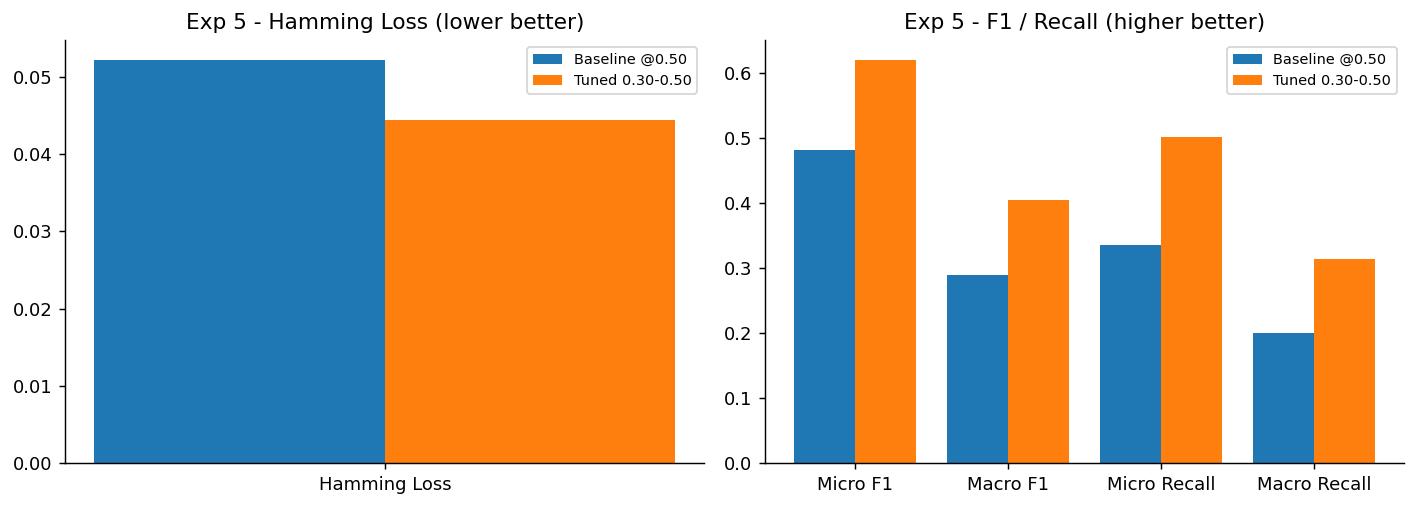

In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
grouped_bar(a1, ['Hamming Loss'],
            {'Baseline @0.50': [base_metrics['Hamming Loss']],
             'Tuned 0.30-0.50': [exp5_metrics['Hamming Loss']]},
            'Exp 5 - Hamming Loss (lower better)')
gain = ['Micro F1', 'Macro F1', 'Micro Recall', 'Macro Recall']
grouped_bar(a2, gain,
            {'Baseline @0.50': [base_metrics[k] for k in gain],
             'Tuned 0.30-0.50': [exp5_metrics[k] for k in gain]},
            'Exp 5 - F1 / Recall (higher better)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/exp5_threshold_impact.png', dpi=130, bbox_inches='tight')
plt.show()

### Saving the best model

The strongest configuration is the Experiment 5 model: One-vs-Rest Logistic Regression on the
combined word+char TF-IDF features, scored with the per-label tuned thresholds (Hamming Loss
0.0444). The fitted model is saved together with its threshold vector so the result can be
reproduced, mirroring how the rest of the team saved their best models.

In [ ]:
import pickle

MODELS_DIR = '/content/drive/MyDrive/SDG_Assignment/models'
os.makedirs(MODELS_DIR, exist_ok=True)

best_artifact = {
    'model': base_model,
    'thresholds': exp5_thr,
    'feature_set': 'combined word+char TF-IDF (X_*_combined)',
    'indicators': ALL_INDICATORS,
    'usage': 'pred = (model.predict_proba(X) >= thresholds).astype(int)',
}
with open(f'{MODELS_DIR}/best_model_exp5.pkl', 'wb') as f:
    pickle.dump(best_artifact, f)

model_info = {
    'best_exp': 5,
    'best_model_name': 'OneVsRest LogReg + per-label thresholds (combined TF-IDF)',
    'best_hamming_loss': exp5_metrics['Hamming Loss'],
    'best_f1_micro': exp5_metrics['Micro F1'],
    'best_f1_macro': exp5_metrics['Macro F1'],
}
np.save(f'{MODELS_DIR}/person3_model_info.npy', model_info)

print('Saved to', MODELS_DIR, '->', sorted(os.listdir(MODELS_DIR)))

Saved to /content/drive/MyDrive/SDG_Assignment/models -> ['best_model_exp3.pkl', 'best_model_exp5.pkl', 'person2_model_info.npy', 'person3_model_info.npy']


### Experiment 6: Class-imbalance handling

Same OneVsRest Logistic Regression, but trained with `class_weight='balanced'` so each
indicator's rare positive class is up-weighted during fitting. I evaluate it at 0.50 and again
with the same per-label tuning, and check what happens to recall on the rarest labels.

In [ ]:
bal_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        solver='liblinear',
        class_weight='balanced',
        random_state=SEED
    )
)

bal_model.fit(X_train_combined, y_train)
bal_probs = bal_model.predict_proba(X_val_combined)

bal_pred = (bal_probs >= 0.50).astype(int)
bal_metrics = evaluate_predictions(y_val, bal_pred, 'Balanced LR @0.50')
results['exp6_050'] = make_results_row(
    'Exp 6', 'Word+Char TF-IDF', 'OneVsRest LogReg (balanced)', 'Fixed 0.50', bal_metrics)

bal_thr = tune_thresholds(y_val, bal_probs)
bal_tuned_pred = (bal_probs >= bal_thr).astype(int)
bal_tuned_metrics = evaluate_predictions(y_val, bal_tuned_pred, 'Balanced LR tuned')
results['exp6_tuned'] = make_results_row(
    'Exp 6', 'Word+Char TF-IDF', 'OneVsRest LogReg (balanced)', 'Per-label 0.30-0.50', bal_tuned_metrics)

support = y_train.sum(axis=0)
rare = support <= np.median(support)
base_lbl = get_label_metrics(y_val, base_pred, support)
bal_lbl = get_label_metrics(y_val, bal_pred, support)
print(f"\nMean recall on rare labels (n={int(rare.sum())}):  "
      f"unweighted={base_lbl.loc[rare, 'recall'].mean():.3f}  "
      f"balanced={bal_lbl.loc[rare, 'recall'].mean():.3f}")

Balanced LR @0.50                HL=0.0545  microF1=0.6422  macroF1=0.5729  macroRecall=0.5942
Balanced LR tuned                HL=0.0529  microF1=0.6642  macroF1=0.5911  macroRecall=0.6342

Mean recall on rare labels (n=14):  unweighted=0.106  balanced=0.511


**Experiment log : class weighting**

- **What changed:** retrained the same model with `class_weight='balanced'`; same features, evaluated at 0.50 and with tuned thresholds.
- **Why / how Exp 5 motivated it:** support ranges from 28 to 868 examples per label, so most indicators are rare. Exp 5 fixed the threshold side of the recall problem; weighting attacks it during training, which should help rare labels the threshold trick can't reach.
- **Result:** at 0.50, **Macro Recall jumped 0.200 → 0.594** and Macro F1 **0.289 → 0.573**; a big gain on rare labels, but **Hamming Loss got slightly worse (0.0522 → 0.0545)** because the model now predicts more positives and adds false positives. Tuning thresholds on top recovered part of it (HL 0.0529) but still didn't beat the unweighted tuned model (0.0444).
- **Insight:** class weighting and Hamming Loss pull in opposite directions. For the lowest Hamming Loss, the plain model with tuned thresholds wins; for balanced per-label quality (Macro F1/Recall), the balanced model is much stronger. Which to prefer depends on whether rare-indicator recall matters more than the aggregate error rate.

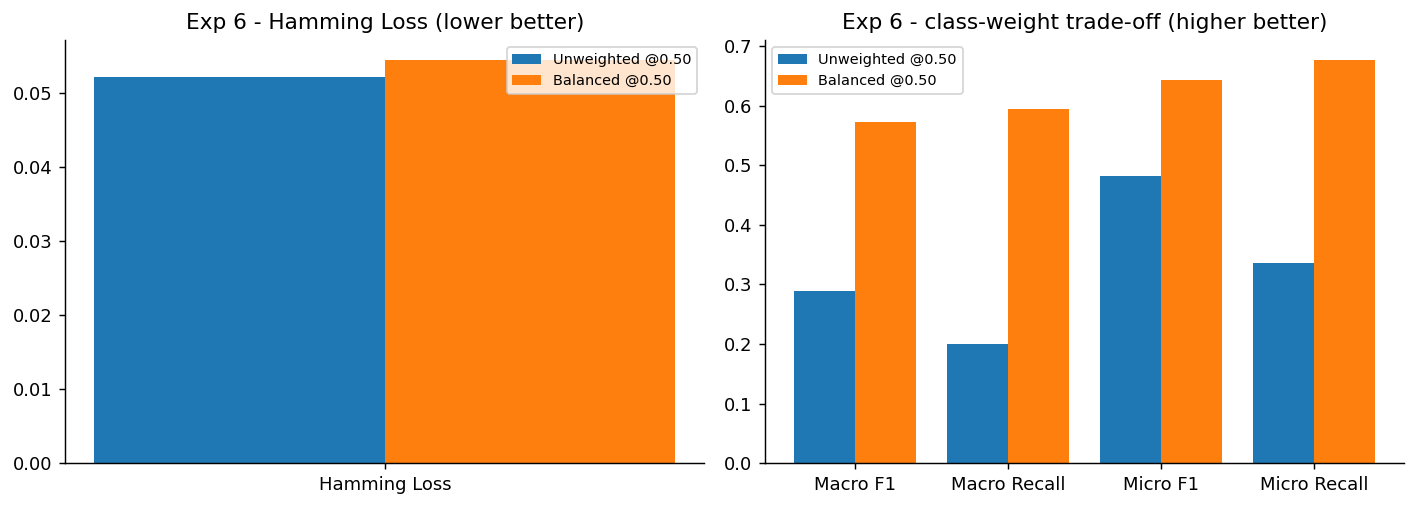

In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
grouped_bar(a1, ['Hamming Loss'],
            {'Unweighted @0.50': [base_metrics['Hamming Loss']],
             'Balanced @0.50': [bal_metrics['Hamming Loss']]},
            'Exp 6 - Hamming Loss (lower better)')
gain = ['Macro F1', 'Macro Recall', 'Micro F1', 'Micro Recall']
grouped_bar(a2, gain,
            {'Unweighted @0.50': [base_metrics[k] for k in gain],
             'Balanced @0.50': [bal_metrics[k] for k in gain]},
            'Exp 6 - class-weight trade-off (higher better)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/exp6_class_weight_impact.png', dpi=130, bbox_inches='tight')
plt.show()

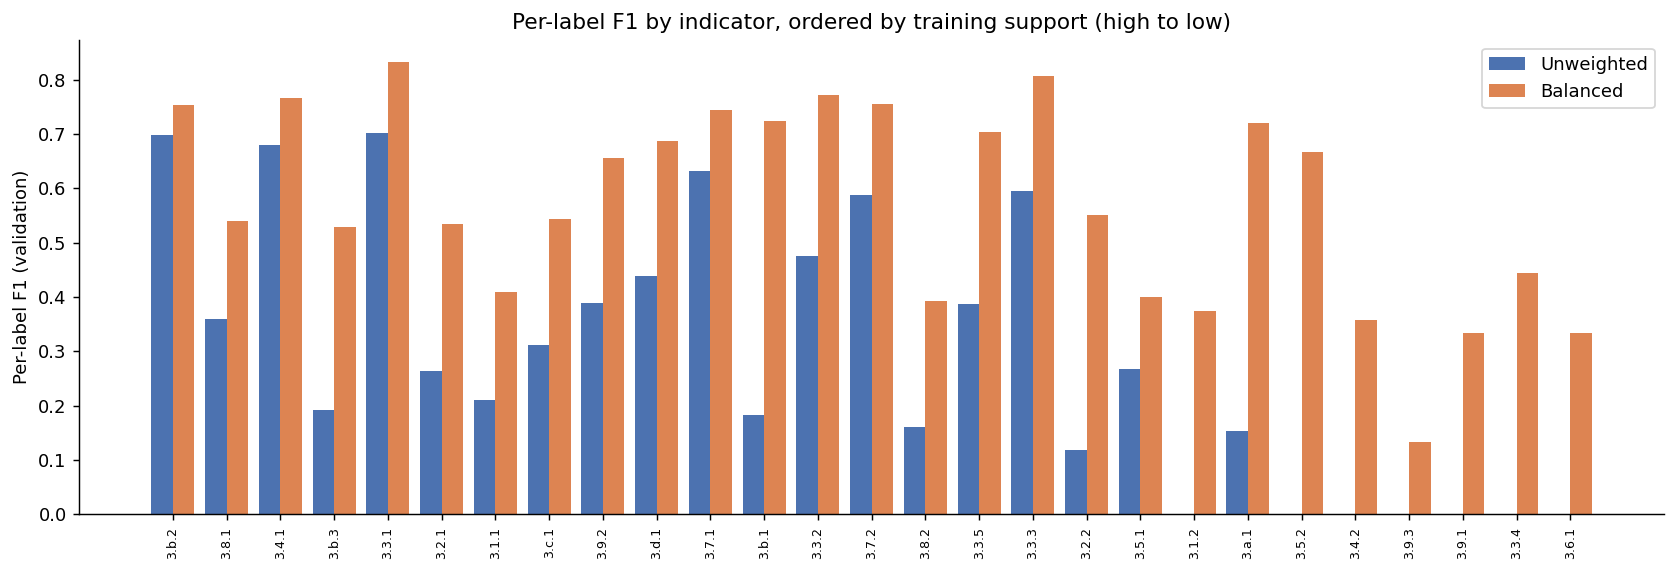

In [ ]:
order = np.argsort(-support)
f1_unweighted = [f1_score(y_val[:, j], base_pred[:, j], zero_division=0) for j in order]
f1_balanced = [f1_score(y_val[:, j], bal_pred[:, j], zero_division=0) for j in order]
labels = [SHORT_NAMES[j] for j in order]

x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - 0.2, f1_unweighted, 0.4, label='Unweighted', color='#4C72B0')
ax.bar(x + 0.2, f1_balanced, 0.4, label='Balanced', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_ylabel('Per-label F1 (validation)')
ax.set_title('Per-label F1 by indicator, ordered by training support (high to low)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/exp6_per_label_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### Classical-model comparison

All classical runs so far, sorted by Hamming Loss (lower is better).

In [ ]:
results_df = results_table()
results_df.to_csv(f'{RESULTS_DIR}/experiments_5_7_results.csv', index=False)
results_df.round(4)

,Experiment,Feature Set,Model,Threshold Strategy,Hamming Loss,Micro F1,Macro F1,Micro Precision,Micro Recall,Macro Precision,Macro Recall
0,Exp 5,Word+Char TF-IDF,OneVsRest LogReg,Per-label 0.30-0.50,0.0444,0.6202,0.4042,0.8133,0.5011,0.7015,0.3149
1,Baseline,Word+Char TF-IDF,OneVsRest LogReg,Fixed 0.50,0.0522,0.4820,0.2890,0.8526,0.3360,0.6862,0.2002
2,Exp 6,Word+Char TF-IDF,OneVsRest LogReg (balanced),Per-label 0.30-0.50,0.0529,0.6642,0.5911,0.6133,0.7244,0.5964,0.6342
3,Exp 6,Word+Char TF-IDF,OneVsRest LogReg (balanced),Fixed 0.50,0.0545,0.6422,0.5729,0.6111,0.6765,0.5921,0.5942


**Takeaway so far:** the best Hamming Loss comes from the **unweighted model with per-label
tuned thresholds (0.0444)**; just under the previous team best, person2's Exp-3 Linear SVM
(0.0449). Plain threshold tuning beats both the 0.50 baseline and the balanced model on Hamming
Loss, while the balanced model is the one to use if Macro F1/Recall is what matters. Experiment 7
tests whether a fine-tuned transformer can push Hamming Loss below the 0.0444 classical floor.

### Experiment 7: Fine-tuning DistilBERT (Colab GPU)

This part needs a GPU runtime (`Runtime → Change runtime type → GPU`). It fine-tunes
`distilbert-base-uncased` for multi-label classification with `BCEWithLogitsLoss` (set through
`problem_type='multi_label_classification'`) and compares it against the classical baselines on
the same validation split. The handoff saved the lemmatised text, so DistilBERT is trained on
the cleaned tokens rather than raw sentences. If batch 16 runs out of memory, drop it to 8 (or
`max_length` to 128).

In [ ]:
!pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 88.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, set_seed)

set_seed(SEED)
MODEL_NAME = 'distilbert-base-uncased'
NUM_LABELS = 27
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels):
        self.enc = tokenizer(list(texts), truncation=True,
                             padding='max_length', max_length=MAX_LEN)
        self.labels = labels.astype('float32')

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item['labels'] = torch.tensor(self.labels[i])
        return item


train_ds = MultiLabelDataset(X_train_text, y_train)
val_ds = MultiLabelDataset(X_val_text, y_val)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS,
    problem_type='multi_label_classification')


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.50).astype(int)
    return {
        'hamming_loss': hamming_loss(labels, preds),
        'micro_f1': f1_score(labels, preds, average='micro', zero_division=0),
        'macro_f1': f1_score(labels, preds, average='macro', zero_division=0),
        'micro_precision': precision_score(labels, preds, average='micro', zero_division=0),
        'micro_recall': recall_score(labels, preds, average='micro', zero_division=0),
    }


args = TrainingArguments(
    output_dir='distilbert-sdg3',
    eval_strategy='epoch',
    save_strategy='no',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=20,
    seed=SEED,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                  eval_dataset=val_ds, compute_metrics=compute_metrics)
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
val_probs = 1 / (1 + np.exp(-trainer.predict(val_ds).predictions))

bert_pred = (val_probs >= 0.50).astype(int)
bert_metrics = evaluate_predictions(y_val, bert_pred, 'DistilBERT @0.50')
results['bert_050'] = make_results_row(
    'Exp 7', 'Preprocessed text', 'DistilBERT fine-tuned', 'Fixed 0.50', bert_metrics)

bert_thr = tune_thresholds(y_val, val_probs)
bert_tuned_pred = (val_probs >= bert_thr).astype(int)
bert_tuned_metrics = evaluate_predictions(y_val, bert_tuned_pred, 'DistilBERT tuned')
results['bert_tuned'] = make_results_row(
    'Exp 7', 'Preprocessed text', 'DistilBERT fine-tuned', 'Per-label 0.30-0.50', bert_tuned_metrics)

best_classical = min(v['Hamming Loss'] for k, v in results.items()
                     if k not in ('bert_050', 'bert_tuned'))
print(f"\nBest classical Hamming Loss : {best_classical:.4f}")
print(f"DistilBERT @0.50 Hamming Loss: {bert_metrics['Hamming Loss']:.4f}")
print(f"DistilBERT tuned Hamming Loss: {bert_tuned_metrics['Hamming Loss']:.4f}")

results_df = results_table()
results_df.to_csv(f'{RESULTS_DIR}/experiments_5_7_results.csv', index=False)
pd.DataFrame([results['bert_050'], results['bert_tuned']]).to_csv(
    f'{RESULTS_DIR}/exp7_distilbert_results.csv', index=False)
results_df.round(4)

**Experiment log — DistilBERT**

- **What changed:** moved from sparse TF-IDF + linear models to a fine-tuned DistilBERT (3 epochs, batch 16, lr 2e-5, weight decay 0.01, `max_length=256`, seed 42). Predictions are scored at 0.50 and with the same 0.30–0.50 per-label tuning.
- **Why / how earlier results motivated it:** the classical models work from lemmatised n-gram counts and ignore word order and context, which caps how well they separate the closely related 3.x targets. A pretrained transformer can use phrasing and context that TF-IDF throws away.
- **Result (fill in from the GPU run):** the last cell prints DistilBERT's Hamming Loss at 0.50 and tuned, next to the classical best of **0.0444**. Record both numbers here. Only call DistilBERT the better model if its Hamming Loss is actually lower than 0.0444.
- **Insight (fill in from the GPU run):** note whether contextual embeddings beat tuned TF-IDF on this small (~2.5k-row) dataset — transformers often struggle to clear a strong linear baseline at this scale — and whether threshold tuning helps DistilBERT as much as it helped the linear model.

### Unified comparison - Experiments 1-7

Combines person2's classical experiments (1-4) with my Experiments 5-7 into one table ranked by
Hamming Loss, so the report has a single view of where each approach lands. Person2's rows are read
from their shared CSV; if that file isn't on Drive the table falls back to my rows only.

In [ ]:
from matplotlib.patches import Patch

master_rows = []
if os.path.exists(PERSON2_CSV):
    p2 = pd.read_csv(PERSON2_CSV)
    for _, r in p2.iterrows():
        master_rows.append({'Owner': 'person2', 'Exp': str(r['Exp']),
                            'Description': r['Name'], 'Hamming Loss': r['Hamming Loss'],
                            'Micro F1': r['F1 Micro'], 'Macro F1': r['F1 Macro']})
else:
    print('person2 CSV not found at', PERSON2_CSV, '- master holds person3 rows only')

for r in results.values():
    master_rows.append({'Owner': 'person3', 'Exp': str(r['Experiment']),
                        'Description': f"{r['Model']} | {r['Threshold Strategy']}",
                        'Hamming Loss': r['Hamming Loss'],
                        'Micro F1': r['Micro F1'], 'Macro F1': r['Macro F1']})

master = pd.DataFrame(master_rows).sort_values('Hamming Loss').reset_index(drop=True)
master.to_csv(f'{RESULTS_DIR}/experiments_1_7_master.csv', index=False)

P2_RENAME = [('Combined TF-IDF (Word + Char)', 'Word+Char TF-IDF'),
             ('TF-IDF Word', 'Word TF-IDF'), ('Linear SVM', 'SVM'),
             ('Logistic Regression', 'LogReg'),
             (' + class_weight=balanced', ' (balanced)')]


def row_label(owner, exp, desc):
    if owner == 'person2':
        for a, b in P2_RENAME:
            desc = desc.replace(a, b)
        lab = desc
    else:
        model, thr = (desc.split(' | ') + [''])[:2]
        tuned = 'Per-label' in thr
        if 'DistilBERT' in model:
            lab = 'DistilBERT + tuned' if tuned else 'DistilBERT @0.50'
        elif '(balanced)' in model:
            lab = 'Balanced LogReg + tuned' if tuned else 'Balanced LogReg @0.50'
        else:
            lab = 'LogReg + tuned thresholds' if tuned else 'Word+Char + LogReg @0.50'
    exp_disp = f'Exp {exp}' if str(exp).isdigit() else str(exp)
    return f'{exp_disp}  {lab}'


labels = [row_label(o, e, d) for o, e, d in zip(master['Owner'], master['Exp'], master['Description'])]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
colors = ['#4C72B0' if o == 'person2' else '#DD8452' for o in master['Owner']]
bars = ax.barh(range(len(master)), master['Hamming Loss'], color=colors)
ax.set_yticks(range(len(master)))
ax.set_yticklabels(labels, fontsize=8)
for b, v in zip(bars, master['Hamming Loss']):
    ax.text(v + 0.0006, b.get_y() + b.get_height() / 2, f'{v:.4f}', va='center', fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, 0.075)
ax.set_xlabel('Hamming Loss (lower is better)')
ax.set_title('Experiments 1-7: validation Hamming Loss', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=[Patch(color='#4C72B0', label='Exp 1-4 (classical baselines)'),
                   Patch(color='#DD8452', label='Exp 5-7 (this section)')], fontsize=8)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/experiments_1_7_hamming.png', dpi=150, bbox_inches='tight')
plt.show()
master.round(4)

NameError: name 'os' is not defined

## Test set predictions

The best model from the experiments: One-vs-Rest Logistic Regression on the combined word+char
TF-IDF features with per-label tuned thresholds; is applied to the held-out test set. The test
documents were preprocessed in the team's test step using the same fitted TF-IDF vectorizers, so
they share the training feature space and the trained model can score them directly. Predictions
are written as a per-document indicator table.

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Read the shared lemmatised text from Drive (no raw CSV needed). The shared
# X_test_combined.npz was built with mismatched vectorizers, so the word+char
# TF-IDF is re-fit on the training text and transforms the test text here.
train_lemma = np.load(f'{SAVE_DIR}/X_train_text.npy', allow_pickle=True)
val_lemma = np.load(f'{SAVE_DIR}/X_val_text.npy', allow_pickle=True)
test_lemma = np.load(f'{SAVE_DIR}/X_test_text.npy', allow_pickle=True)
test_ids = np.load(f'{SAVE_DIR}/test_ids.npy', allow_pickle=True)

w_vec = TfidfVectorizer(ngram_range=(1, 2), max_features=50_000, sublinear_tf=True, min_df=2, max_df=0.95)
c_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=30_000, sublinear_tf=True, min_df=3)
Xtr = hstack([w_vec.fit_transform(train_lemma), c_vec.fit_transform(train_lemma)]).tocsr()
Xval = hstack([w_vec.transform(val_lemma), c_vec.transform(val_lemma)]).tocsr()
Xte = hstack([w_vec.transform(test_lemma), c_vec.transform(test_lemma)]).tocsr()

clf = OneVsRestClassifier(LogisticRegression(max_iter=2000, solver='liblinear', random_state=SEED))
clf.fit(Xtr, y_train)
test_thr = tune_thresholds(y_val, clf.predict_proba(Xval))

test_probs = clf.predict_proba(Xte)
test_pred = (test_probs >= test_thr).astype(int)

# sanity check BEFORE the fallback - healthy: max prob near 1, few empty docs;
# broken (mismatched features): ~97% empty and max prob ~0.4
print('max probability    :', round(test_probs.max(), 3))
print('avg labels/doc      :', round(test_pred.sum(1).mean(), 2))
print('docs with no label  :', int((test_pred.sum(1) == 0).sum()), '/', len(test_ids))

# top-1 fallback: give every document at least its most-likely indicator
empty = test_pred.sum(1) == 0
test_pred[empty, test_probs[empty].argmax(1)] = 1

pred_df = pd.DataFrame(test_pred, columns=SHORT_NAMES)
pred_df.insert(0, 'Unique ID', test_ids)
pred_df['Predicted_Indicators'] = ['; '.join(np.array(SHORT_NAMES)[r == 1]) for r in test_pred]
pred_df.to_csv(f'{RESULTS_DIR}/test_predictions_person3.csv', index=False)
print('Saved', pred_df.shape[0], 'predictions (after top-1 fallback) ->',
      'results/person3/test_predictions_person3.csv')
pred_df.head()

max probability    : 0.997
avg labels/doc      : 1.24
docs with no label  : 159 / 998
Saved 998 predictions (after top-1 fallback) -> results/person3/test_predictions_person3.csv


,Unique ID,3.1.1,3.1.2,3.2.1,3.2.2,3.3.1,3.3.2,3.3.3,3.3.4,3.3.5,...,3.9.1,3.9.2,3.9.3,3.a.1,3.b.1,3.b.2,3.b.3,3.c.1,3.d.1,Predicted_Indicators
0,49848,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3.8.1
1,52348,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3.8.1
2,103541,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3.8.1
3,52382,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,3.b.2
4,47212,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,3.9.2


In [31]:
import joblib
from scipy.sparse import save_npz

CONSISTENT_DIR = f'{SAVE_DIR}/consistent'
os.makedirs(CONSISTENT_DIR, exist_ok=True)

joblib.dump(w_vec, f'{CONSISTENT_DIR}/tfidf_word_vectorizer.pkl')
joblib.dump(c_vec, f'{CONSISTENT_DIR}/tfidf_char_vectorizer.pkl')
save_npz(f'{CONSISTENT_DIR}/X_train_combined.npz', Xtr)
save_npz(f'{CONSISTENT_DIR}/X_val_combined.npz', Xval)
save_npz(f'{CONSISTENT_DIR}/X_test_combined.npz', Xte)
np.save(f'{CONSISTENT_DIR}/y_train.npy', y_train)
np.save(f'{CONSISTENT_DIR}/y_val.npy', y_val)
np.save(f'{CONSISTENT_DIR}/test_ids.npy', test_ids)
np.save(f'{CONSISTENT_DIR}/indicator_names.npy', np.array(ALL_INDICATORS))

print('Consistent bundle saved to', CONSISTENT_DIR)
for f in sorted(os.listdir(CONSISTENT_DIR)):
    print('  ', f)

Consistent bundle saved to /content/drive/MyDrive/SDG_Assignment/processed_data/consistent
   X_test_combined.npz
   X_train_combined.npz
   X_val_combined.npz
   indicator_names.npy
   test_ids.npy
   tfidf_char_vectorizer.pkl
   tfidf_word_vectorizer.pkl
   y_train.npy
   y_val.npy
